# 🌍 2024 - 2025 - 2026: Elektrik Piyasası Rejim Değişimi (Regime Shift) Analizi

Türkiye elektrik piyasasında son 3 yılda yenilenebilir enerji kapasitelerindeki artışın, piyasa fiyatlarına ve saatlik dengelere (Duck Curve) nasıl devasa bir şok uyguladığını görselleştiren özel analiz raporudur.

**Bu notebook'un amacı sunum ve makaleler için 3 temel kanıt sunmaktır:**

1. Yıllara Göre Yenilenebilir Enerji (Güneş + Rüzgar) Baskısı.
2. Sıfır Fiyat (Sıfır ve Sıfıra Yakın Fiyat) Saatlerinin Yıllara Göre Patlaması.
3. Gündüz Saatlerindeki Fiyat Çöküşünün (Ördek Eğrisinin Derinleşmesi) Yıllık Kıyaslaması.


In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('dark_background')
sns.set_palette("Set2")
plt.rcParams['figure.figsize'] = (14, 7)

# DB Bağlantısı
project_root = os.path.abspath("..")
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from db.connection import get_db_engine
from sqlalchemy import text

print("📦 Veritabanından 2024-2026 arası saatlik PTF, Yenilenebilir ve Tüketim verileri çekiliyor...")
engine = get_db_engine()
master_sql = text('''
    SELECT 
        m.ts,
        m.price_usd AS mcp_price_usd,
        k.wind_mw AS kgup_wind_mw,
        k.solar_mw AS kgup_solar_mw,
        c.consumption_mw AS actual_cons_mw
    FROM raw_mcp_hourly m
    LEFT JOIN raw_kgup_hourly k ON m.ts = k.ts
    LEFT JOIN raw_actual_consumption_hourly c ON m.ts = c.ts
    WHERE m.ts >= '2024-01-01' AND m.ts < '2026-12-31'
    ORDER BY m.ts ASC;
''')

with engine.connect() as conn:
    df = pd.read_sql(master_sql, conn)

df['ts'] = pd.to_datetime(df['ts']).dt.tz_convert('Europe/Istanbul')
df = df.set_index('ts').sort_index()
df = df.ffill().bfill()

# Tarihsel Bileşenler
df['year'] = df.index.year
df['hour'] = df.index.hour
df['month'] = df.index.month
df['renewable_mw'] = df['kgup_wind_mw'] + df['kgup_solar_mw']
df['renewable_ratio'] = (df['renewable_mw'] / df['actual_cons_mw']) * 100

print(f"✅ Veri Hazır: Toplam {len(df):,} saatlik kayıt.")


📦 Veritabanından 2024-2026 arası saatlik PTF, Yenilenebilir ve Tüketim verileri çekiliyor...
✅ Veri Hazır: Toplam 22,752 saatlik kayıt.


## 1. Yıllara Göre Yenilenebilir Enerji (Rüzgar + Güneş) Oranının Gelişimi

Yenilenebilir enerjinin toplam tüketimi karşılama oranının (Renewable Ratio) 2024'ten 2026'ya nasıl arttığına bakalım.


/var/folders/fg/9flc738d345c3sdd8tq2cln80000gn/T/ipykernel_74187/449242961.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=yearly_stats, x='year', y='renewable_ratio', ax=ax1, palette='viridis', alpha=0.8)


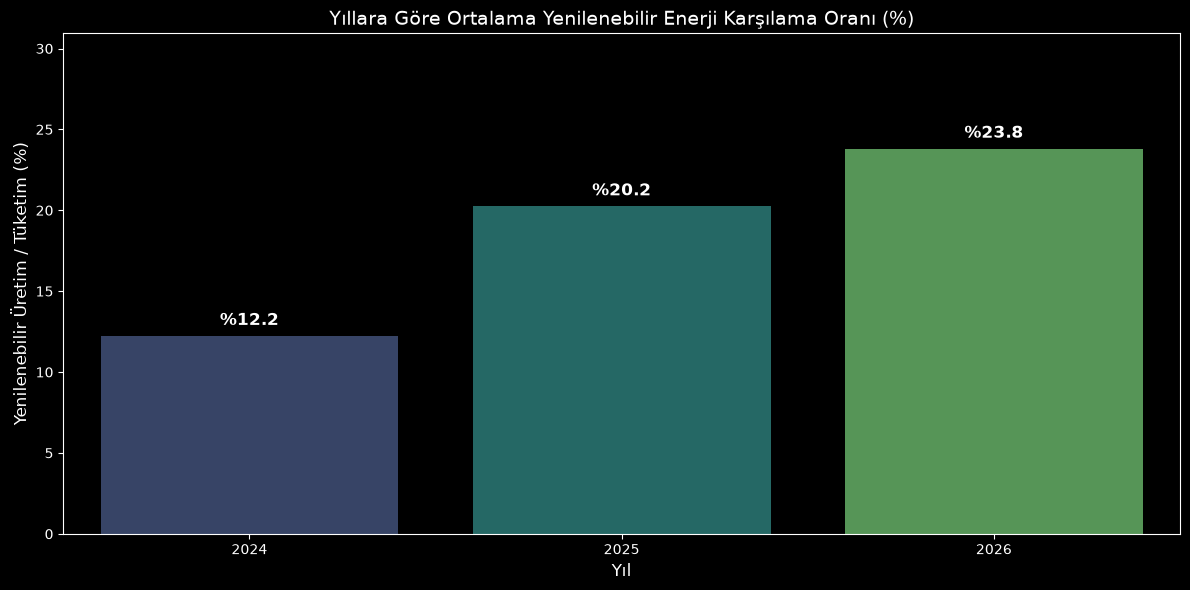

In [2]:
yearly_stats = df.groupby('year').agg({
    'renewable_ratio': 'mean',
    'renewable_mw': 'mean',
    'mcp_price_usd': 'mean'
}).reset_index()

fig, ax1 = plt.subplots(figsize=(12, 6))

sns.barplot(data=yearly_stats, x='year', y='renewable_ratio', ax=ax1, palette='viridis', alpha=0.8)
ax1.set_title('Yıllara Göre Ortalama Yenilenebilir Enerji Karşılama Oranı (%)', fontsize=14)
ax1.set_ylabel('Yenilenebilir Üretim / Tüketim (%)', fontsize=12)
ax1.set_xlabel('Yıl', fontsize=12)
ax1.set_ylim(0, yearly_stats['renewable_ratio'].max() * 1.3)

for p in ax1.patches:
    ax1.annotate(f"%{p.get_height():.1f}", (p.get_x() + p.get_width() / 2., p.get_height()), 
                 ha='center', va='bottom', fontsize=12, fontweight='bold', color='white', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()


## 2. Sıfır Fiyat (Dip Fiyat) Rejiminin Doğuşu

Piyasa fiyatının $5/MWh ve altına düştüğü ekstrem saatlerin yıllara göre sayısını inceliyoruz. Bu, rejimin en net kanıtıdır.


/var/folders/fg/9flc738d345c3sdd8tq2cln80000gn/T/ipykernel_74187/3607900528.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=zero_price_counts, x='year', y='is_zero_price', palette='magma')


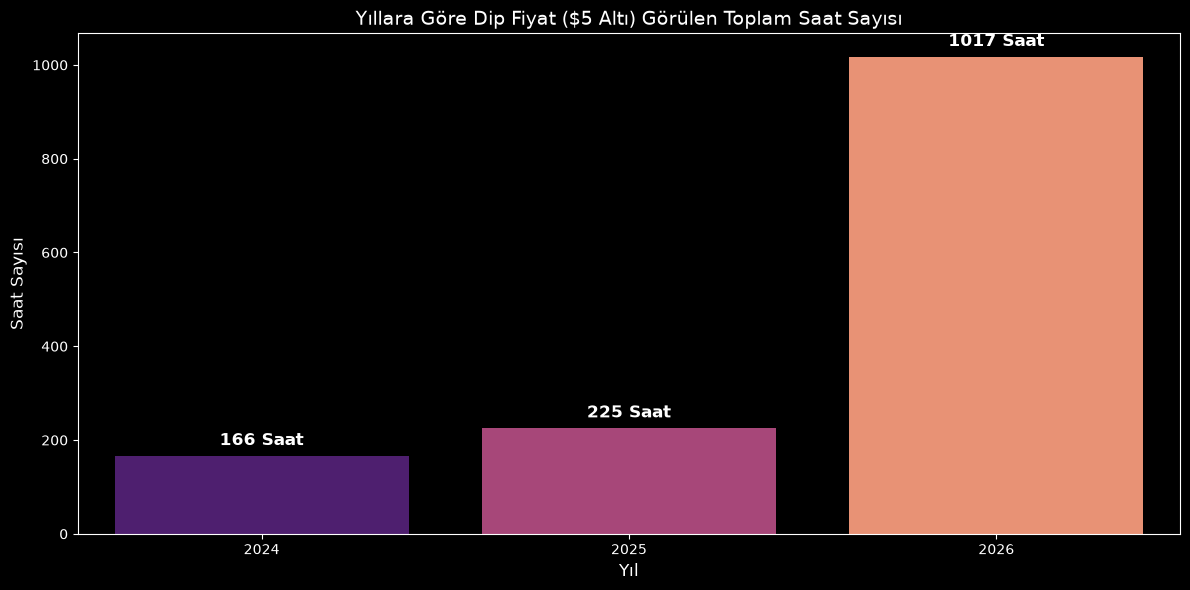

In [3]:
# Fiyatı 5 Doların altına inen (Dip yapan) saatlerin sayısı
df['is_zero_price'] = df['mcp_price_usd'] <= 5.0
zero_price_counts = df.groupby('year')['is_zero_price'].sum().reset_index()

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=zero_price_counts, x='year', y='is_zero_price', palette='magma')

ax.set_title('Yıllara Göre Dip Fiyat ($5 Altı) Görülen Toplam Saat Sayısı', fontsize=14, color='white')
ax.set_ylabel('Saat Sayısı', fontsize=12)
ax.set_xlabel('Yıl', fontsize=12)

for p in ax.patches:
    ax.annotate(f"{int(p.get_height())} Saat", (p.get_x() + p.get_width() / 2., p.get_height()), 
                 ha='center', va='bottom', fontsize=12, fontweight='bold', color='white', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()


## 3. Ördek Eğrisinin (Duck Curve) Derinleşmesi: Bahar Ayları (Mart-Mayıs)

Güneş enerjisi üretiminin en çok piyasayı bozduğu Bahar aylarında (Öğle saatleri), fiyat çöküşünün 2024'ten 2026'ya nasıl derinleştiğini (Rejim Değişikliğini) saatlik profil olarak görelim.


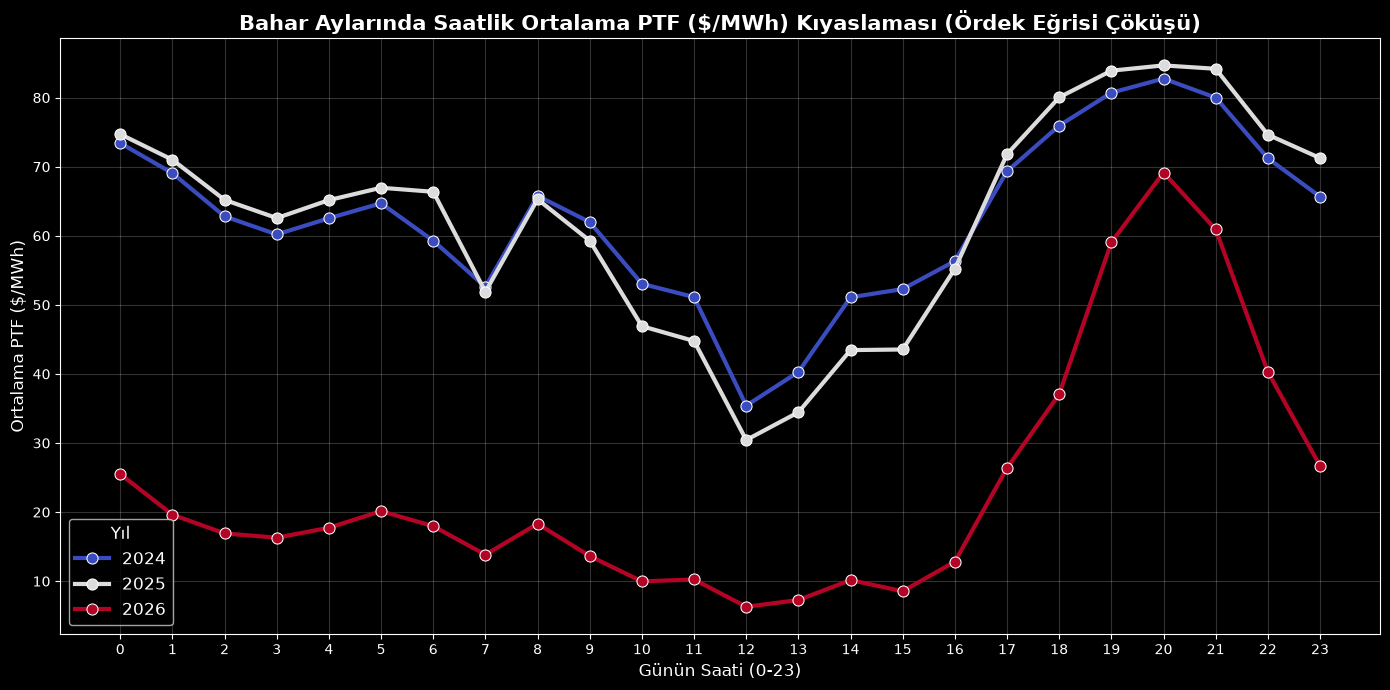

In [4]:
# Sadece Bahar aylarını filtreleyelim (Mart, Nisan, Mayıs)
spring_df = df[df['month'].isin([3, 4, 5])]
hourly_spring_profile = spring_df.groupby(['year', 'hour'])['mcp_price_usd'].mean().reset_index()

fig, ax = plt.subplots(figsize=(14, 7))
sns.lineplot(data=hourly_spring_profile, x='hour', y='mcp_price_usd', hue='year', 
             marker='o', linewidth=3, markersize=8, palette='coolwarm')

ax.set_title('Bahar Aylarında Saatlik Ortalama PTF ($/MWh) Kıyaslaması (Ördek Eğrisi Çöküşü)', fontsize=15, fontweight='bold')
ax.set_xlabel('Günün Saati (0-23)', fontsize=12)
ax.set_ylabel('Ortalama PTF ($/MWh)', fontsize=12)
ax.set_xticks(range(0, 24))
ax.grid(alpha=0.2)
plt.legend(title='Yıl', fontsize=12, title_fontsize=12)

plt.tight_layout()
plt.show()
